# 1. Carga y exploración inicial de los datos

Para comenzar, se importan las librerías necesarias para la manipulación, visualización y preparación de los datos. Posteriormente, se carga el conjunto de datos de desempeño estudiantil desde GitHub.

Una vez cargada la información, se elimina la variable `final_grade`, ya que el análisis se enfoca en utilizar `final_exam_score` como variable objetivo. Finalmente, se muestran las primeras observaciones del conjunto de datos para comprobar que la información se cargó correctamente y conocer las variables disponibles.

Esta primera etapa permite identificar la estructura del conjunto de datos antes de realizar el análisis, la preparación de las variables y la construcción de la red neuronal.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [6]:
csv_path = "https://raw.githubusercontent.com/a01753010-ui/Portafolio1_Emilio_Torres/main/Entrega2/student_performance_dataset.csv"
df = pd.read_csv(csv_path)
df = df.drop('final_grade', axis = 1)
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3


# 2. Análisis y preparación de los datos

Una vez cargado el conjunto de datos, se realiza una primera preparación de las variables con el objetivo de facilitar su análisis y conocer la relación existente entre las diferentes características de los estudiantes.

Las variables se separan en dos grupos: variables numéricas y variables categóricas. Las variables numéricas consideradas son `study_time_hours`, `attendance_percent`, `sleep_hours` y `final_exam_score`, mientras que las variables categóricas corresponden a `gender`, `parental_education`, `internet_access`, `extracurricular_activities` y `part_time_job`.

Para las variables numéricas se utiliza `StandardScaler`, que estandariza sus valores, mientras que las variables categóricas se convierten a una representación numérica mediante *One-Hot Encoding*. De esta manera, las categorías pueden incorporarse al análisis matemático. Posteriormente, ambas transformaciones se combinan mediante un `ColumnTransformer` y se genera un nuevo conjunto de datos procesado.

Finalmente, se calcula una matriz de correlación y se representa mediante un mapa de calor. Esta visualización permite identificar qué variables presentan relaciones lineales más fuertes o más débiles entre sí y sirve como una primera referencia para analizar qué características podrían estar relacionadas con la calificación del examen final.

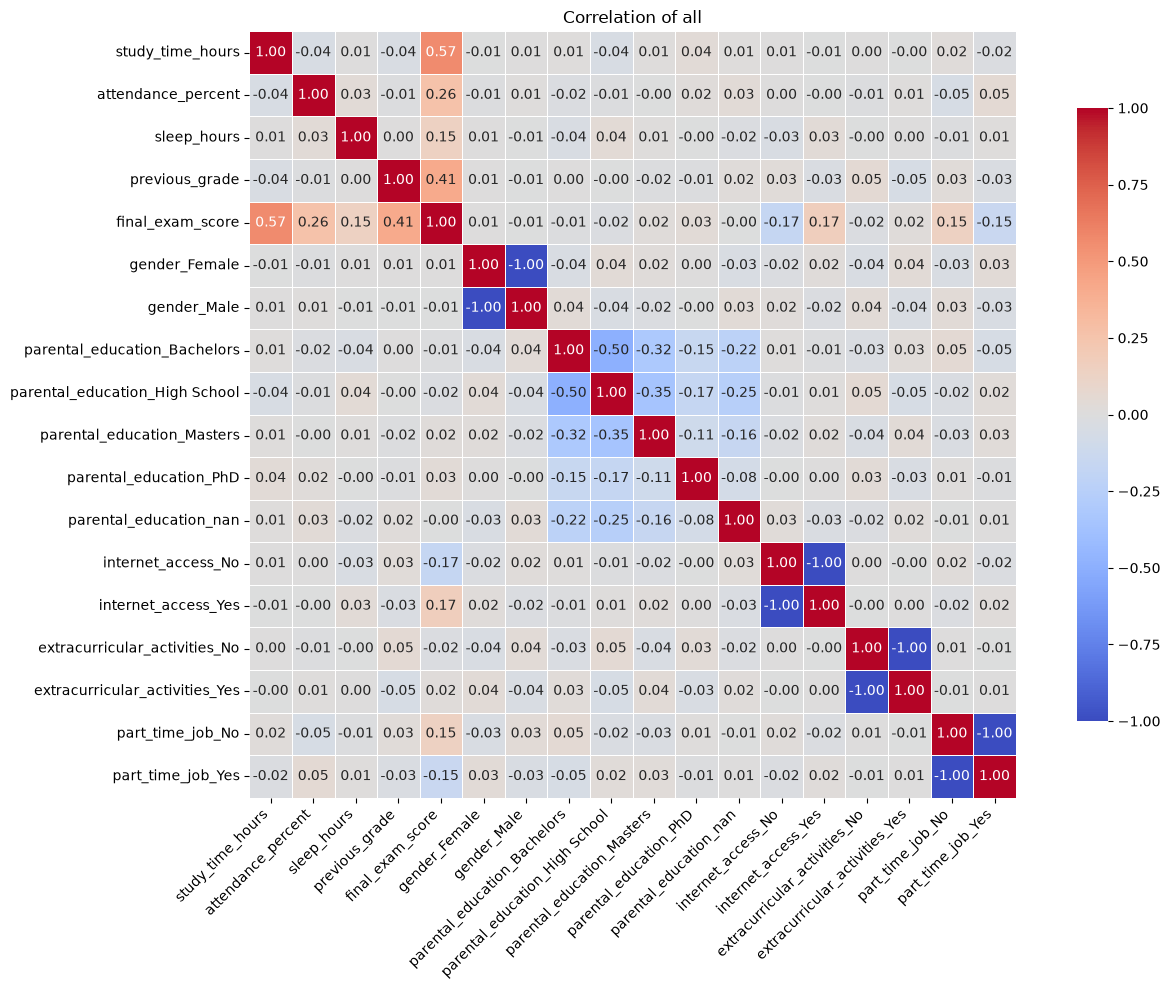

In [7]:
# Correctly define numeric and categorical features
numeric_features = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade','final_exam_score']
categorical_features = ['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# Fit and transform the data
df_processed_array = preprocessor.fit_transform(df)
numeric_feature_names = numeric_features
categorical_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
# Combine all feature names
all_feature_names = list(numeric_feature_names) + list(categorical_feature_names)

# Create a new DataFrame with processed data
df_processed = pd.DataFrame(df_processed_array, columns=all_feature_names)

corr_matrix = df_processed.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)
plt.title('Correlation of all')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

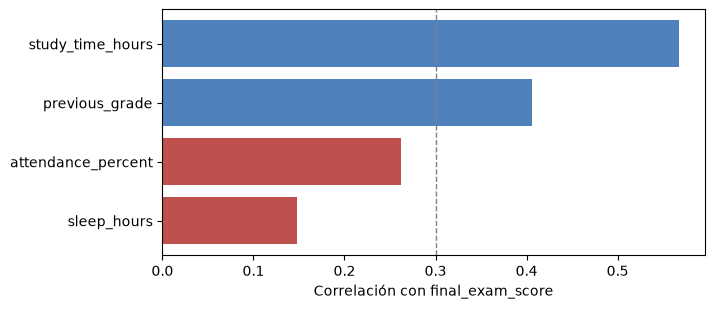

In [17]:
# Correlación de cada variable numérica con la calificación final
df_final = df.drop(['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job','student_id'], axis=1)
num = df_final.select_dtypes(include=[np.number])
corr = num.corr()['final_exam_score'].drop('final_exam_score').sort_values()

colors = ['#4f81bd' if v > 0.3 else '#c0504d' for v in corr.values]
plt.figure(figsize=(7, 3.2))
plt.barh(corr.index, corr.values, color=colors)
plt.axvline(0.3, ls='--', c='gray', lw=1)  # línea de referencia
plt.xlabel('Correlación con final_exam_score')
plt.show()